In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("train.csv")

df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584


In [3]:
df.shape

(40000, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   experience    40000 non-null  int64
 1   country       40000 non-null  str  
 2   education     40000 non-null  str  
 3   languages     40000 non-null  str  
 4   frameworks    40000 non-null  str  
 5   company_size  40000 non-null  str  
 6   salary_usd    40000 non-null  int64
dtypes: int64(2), str(5)
memory usage: 2.1 MB


In [5]:
df.describe()

,experience,salary_usd
count,40000.000000,40000.000000
mean,19.912875,131834.441525
std,11.865220,46426.249810
min,0.000000,12024.000000
25%,10.000000,98172.250000
50%,20.000000,130579.000000
75%,30.000000,164431.000000
max,40.000000,277554.000000


In [6]:
df.isnull().sum()

experience      0
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['country'].unique()
df['education'].unique()
df['company_size'].unique()

<StringArray>
['201-1000', '5000+', '11-50', '1-10', '51-200', '1001-5000']
Length: 6, dtype: str

<Axes: ylabel='salary_usd'>

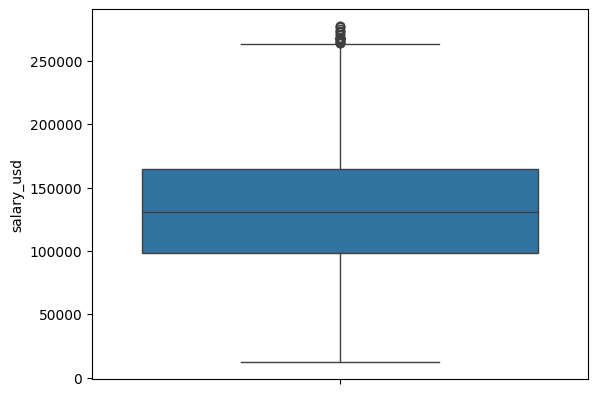

In [9]:
sns.boxplot(df['salary_usd'])

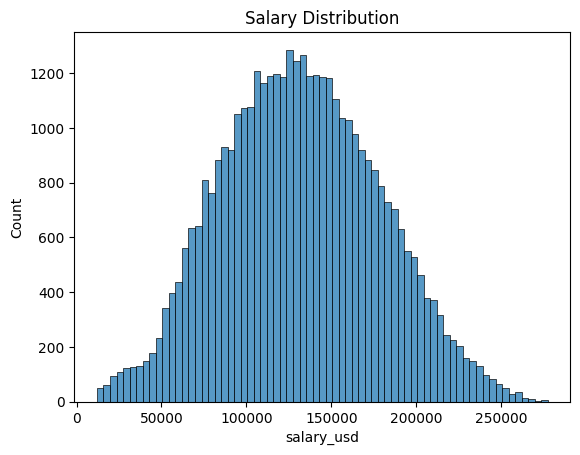

In [10]:
sns.histplot(df['salary_usd'])
plt.title("Salary Distribution")
plt.show()

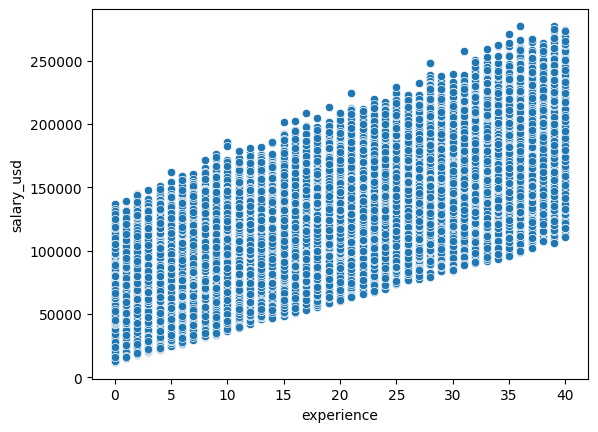

In [11]:
sns.scatterplot(x=df['experience'], y=df['salary_usd'])
plt.show()



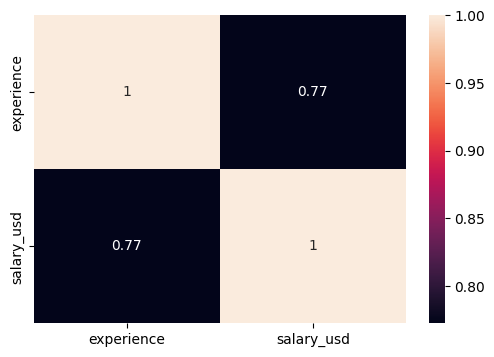

In [12]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6,4))
sns.heatmap(num_df.corr(), annot=True)
plt.show()

In [13]:
df['salary_per_experience'] = df['salary_usd'] / (df['experience'] + 1)
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd,salary_per_experience
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292,4922.628571
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311,8231.100000
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637,12181.888889
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386,7146.200000
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584,13448.000000


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('salary_usd', axis=1)
y = df['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (32000, 7)
X_test shape: (8000, 7)
y_train shape: (32000,)
y_test shape: (8000,)


In [15]:
#drop non-numeric before scaling
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
pd.DataFrame(X_train).head()

,0,1
0,-0.665577,-0.391364
1,0.262130,-0.530470
2,1.611523,-0.417554
3,-0.496903,-0.410510
4,0.768152,-0.263867


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 88247.81085164, 169022.86598273, 125620.35987563,  73137.8011991 ,
        82142.83246796])

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 22965.03913317421
MSE: 815323247.9883074
RMSE: 28553.86572757369
R2 Score: 0.6212758316357456


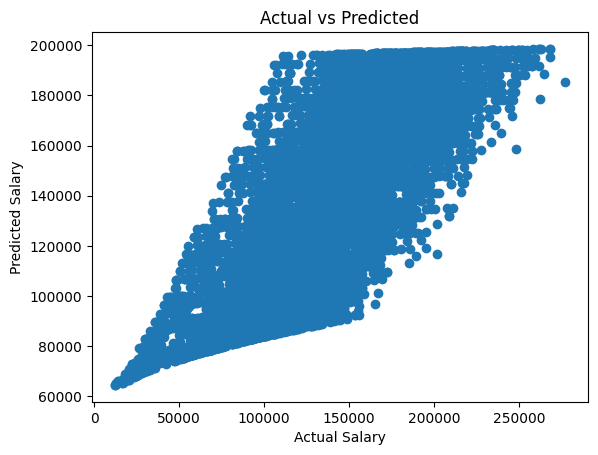

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()